In [25]:
import pandas as pd
import matplotlib.pyplot as plt 

In [26]:
data = pd.read_csv('data.csv')
data.head()


,Order_ID,Date,Customer_ID,Product,Category,Price,Quantity,City
0,1001,2023-02-21,C192,Bag,Accessories,55386.0,2.0,Jaipur
1,1002,2023-01-11,C174,Bag,Accessories,44631.0,4.0,Jaipur
2,1003,2023-02-22,C101,Watch,Accessories,60235.0,4.0,Chennai
3,1004,2023-01-02,C163,Watch,Accessories,54207.0,2.0,Chennai
4,1005,2023-02-18,C190,Camera,Electronics,26158.0,3.0,Mumbai


In [27]:
data.isnull().sum()

Order_ID        0
Date            0
Customer_ID     0
Product         0
Category        0
Price          10
Quantity       10
City           10
dtype: int64

In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
data["Date"] = pd.to_datetime(data["Date"])

In [30]:
data['Total Sales'] = data["Quantity"] * data["Price"]
data["Total Sales"].head()

0    110772.0
1    178524.0
2    240940.0
3    108414.0
4     78474.0
Name: Total Sales, dtype: float64

In [31]:
sales_by_category = data.groupby('Category')['Total Sales'].sum()


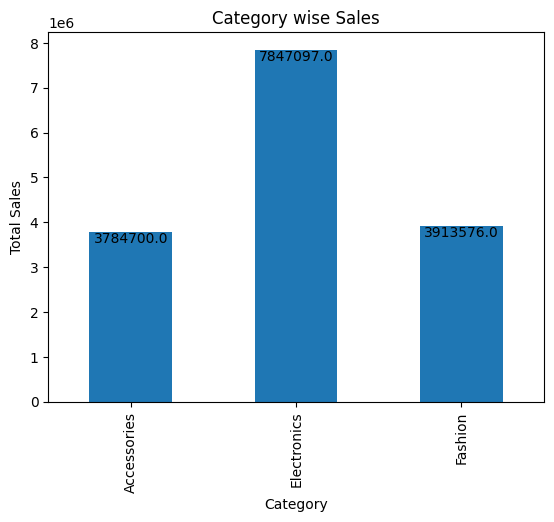

In [32]:

sales_by_category.plot(kind='bar')
plt.title("Category wise Sales")
plt.ylabel("Total Sales")
for i, value in enumerate(sales_by_category):
    plt.text(i, value, str(value), ha='center', va='top')

Text(0, 0.5, '')

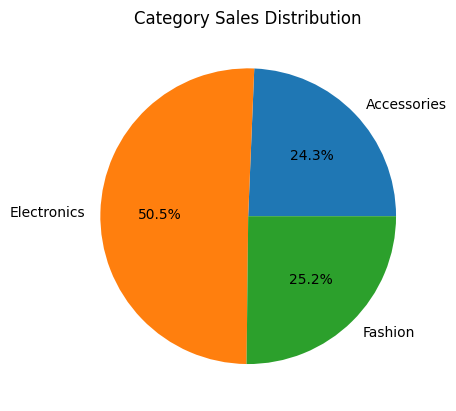

In [33]:
sales_by_category.plot(kind = "pie", autopct='%1.1f%%')
plt.title("Category Sales Distribution")
plt.ylabel("")


In [34]:
product_sales = data.groupby('Product')['Total Sales'].sum()

In [35]:
product_sales

Product
Bag           1844703.0
Camera        1547036.0
Headphones    1309290.0
Keyboard      1140822.0
Laptop        1375714.0
Phone         1379900.0
Shoes         1583858.0
T-shirt       2329718.0
Tablet        1094335.0
Watch         1939997.0
Name: Total Sales, dtype: float64

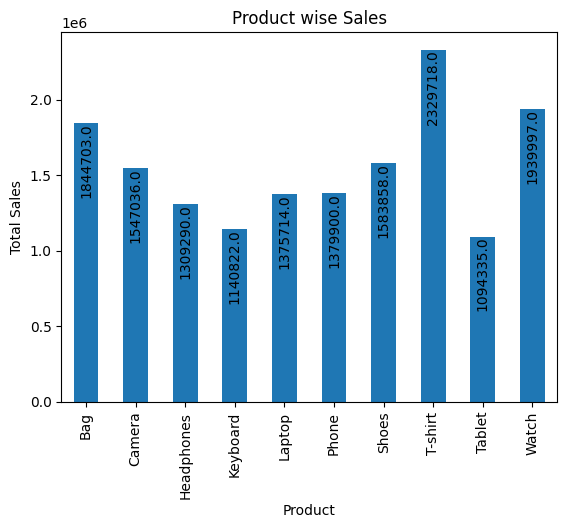

In [36]:
product_sales.plot(kind = "bar")
plt.title("Product wise Sales")
plt.ylabel("Total Sales")
for i, value in enumerate(product_sales):
    plt.text(i, value, str(value), ha='center', va='top', rotation=90)


Text(0, 0.5, '')

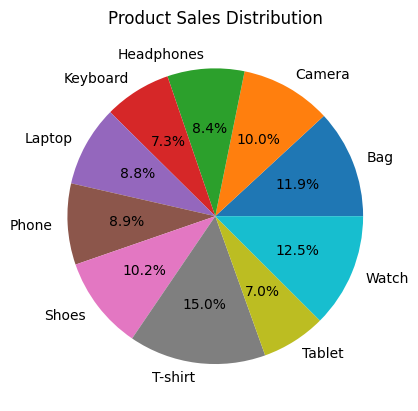

In [37]:
product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Sales Distribution")
plt.ylabel("")

In [38]:
daily_sales = data.groupby('Date')['Total Sales'].sum()

Text(0, 0.5, 'Total Sales')

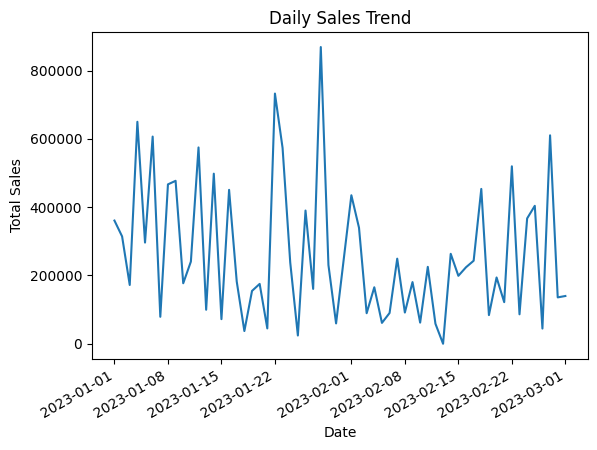

In [39]:
daily_sales.plot(kind='line')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")   


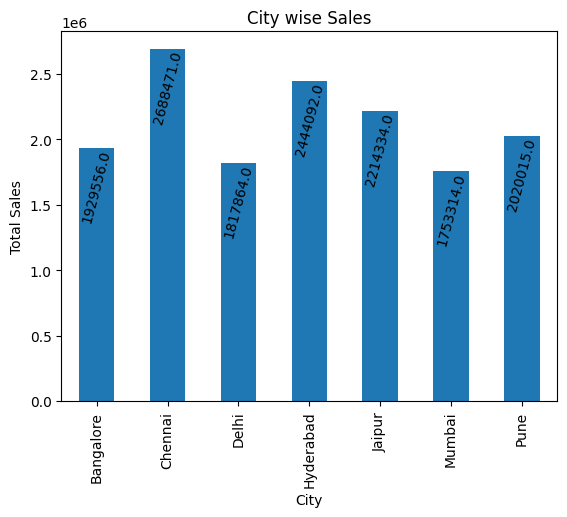

In [40]:
city_sales = data.groupby('City')['Total Sales'].sum()
city_sales.plot(kind='bar')
plt.title("City wise Sales")
plt.ylabel("Total Sales")
for i, value in enumerate(city_sales):
    plt.text(i, value, str(value), ha='center', va='top',rotation=75)

In [41]:
X = data[["Quantity", "Price"]]
Y = data["Total Sales"]



In [42]:
data["Price"] = data["Price"].fillna(data["Price"].mean(), inplace=True)
data["Quantity"] = data["Quantity"].fillna(data["Quantity"].mean(), inplace=True)
data["Total Sales"] = data["Total Sales"].fillna(data["Total Sales"].mean(), inplace=True)

C:\Users\ROHIT NAGAR\AppData\Local\Temp\ipykernel_15340\297967150.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Price"] = data["Price"].fillna(data["Price"].mean(), inplace=True)
C:\Users\ROHIT NAGAR\AppData\Local\Temp\ipykernel_15340\297967150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [43]:
data.isnull().sum()


Order_ID         0
Date             0
Customer_ID      0
Product          0
Category         0
Price          200
Quantity       200
City            10
Total Sales    200
dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [45]:
# from sklearn.linear_model import LinearRegression';.
# model = LinearRegression()
# model.fit(X_train, Y_train)

In [46]:
# y_pred = model.predict(X_test)

In [47]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# mse = mean_squared_error(Y_test, y_pred)
# mae = mean_absolute_error(Y_test, y_pred)
# r2 = r2_score(Y_test, y_pred)
# print(f"Mean Squared Error: {mse}")
# print(f"Mean Absolute Error: {mae}")
# print(f"R^2 Score: {r2}")

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
rf_y_pred = rf_model.predict(X_test)


In [49]:
mae_rf = mean_absolute_error(Y_test, rf_y_pred)
print(f"Random Forest Mean Absolute Error: {mae_rf}")
mse_rf = mean_squared_error(Y_test, rf_y_pred)
print(f"Random Forest Mean Squared Error: {mse_rf}")
r2_rf = r2_score(Y_test, rf_y_pred)
print(f"Random Forest R^2 Score: {r2_rf}")

Random Forest Mean Absolute Error: 5504.425291367408
Random Forest Mean Squared Error: 175370451.58168903
Random Forest R^2 Score: 0.8721155025046674
